# Convolutional Neural Networks: Foundations

In this notebook, you will learn the basic building blocks of convolutional neural networks for image classification.

We will start with manual image filters, then connect these operations to PyTorch CNN layers. You will implement and inspect:

1. **Convolution operations** — edge detection, blur filters, stride, and padding
2. **Pooling operations** — reducing spatial size while keeping important activations
3. **CNN layers in PyTorch** — `Conv2d`, `ReLU`, and `MaxPool2d`
4. **A complete CNN classifier** — feature extraction followed by classification
5. **CNN training and evaluation** — training a small CNN on FashionMNIST
6. **Feature map visualization** — inspecting what early convolutional filters detect

By the end, you should understand how images move through a CNN and how spatial feature maps are transformed into class predictions.

**Note:** The reflection questions are not graded. They are included to help you deepen your understanding. Only the coding tasks marked as tasks are graded.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import models
from PIL import Image

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Understanding Convolution Operations: Manual Convolution, Edge and Blur filters

Convolutional Neural Networks (CNNs) are designed to efficiently process grid-like data such as images. The key innovation is the **convolution operation**, which applies filters across the input to detect features.

Key advantages of CNNs for image processing:
- **Preserve spatial structure** - 2D arrangement of pixels is maintained
- **Local receptive fields** - Each neuron only looks at a small region of the input
- **Parameter sharing** - The same filter is applied across the entire image
- **Translation invariance** - Features detected in one part of the image can be detected anywhere

Let's implement a simple 2D convolution operation from scratch to understand how it works:

#### Note: Convolution vs. Cross-Correlation

In mathematics, a true convolution flips the kernel before applying it.
In most deep learning libraries, including PyTorch, the operation called `Conv2d` does **not** flip the kernel. Technically, this is cross-correlation.

We will still call it “convolution” here because this is the standard terminology used in CNNs.

In [3]:
def conv2d_simple(input_image, kernel, stride=1, padding=0):
    """
    Implement a simple CNN-style 2D convolution operation.

    Note:
    This implementation does not flip the kernel. Therefore, it is technically
    cross-correlation, which is also what deep learning libraries usually use.

    Args:
        input_image: 2D numpy array (height, width)
        kernel: 2D numpy array (kernel_height, kernel_width)
        stride: Step size for moving the kernel
        padding: Number of zeros to add around the input image

    Returns:
        2D numpy array containing the filter response
    """
    kernel_height, kernel_width = kernel.shape

    if padding > 0:
        padded_image = np.pad(input_image, pad_width=padding, mode="constant")
    else:
        padded_image = input_image

    padded_height, padded_width = padded_image.shape

    output_height = (padded_height - kernel_height) // stride + 1
    output_width = (padded_width - kernel_width) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            row_start = i * stride
            col_start = j * stride

            roi = padded_image[
                row_start:row_start + kernel_height,
                col_start:col_start + kernel_width
            ]

            output[i, j] = np.sum(roi * kernel)

    return output

In [4]:
# Create a complex synthetic image
image = np.zeros((80, 80))

# Bright square
image[10:35, 10:35] = 1.0

# Less bright rectangle
image[45:70, 10:45] = 0.7

# Circle
yy, xx = np.ogrid[:80, :80]
circle = (yy - 35) ** 2 + (xx - 58) ** 2 <= 15 ** 2
image[circle] = 1.0

# Diagonal line
for i in range(15, 65):
    image[i, i] = 1.0
    image[i, i + 1] = 1.0

### Sobel Edge Kernels

The filters below are Sobel edge detection kernels.
They respond strongly to changes in brightness.

The horizontal Sobel kernel detects horizontal edges, where intensity changes from top to bottom.
The vertical Sobel kernel detects vertical edges, where intensity changes from left to right.

Sobel kernels also give more weight to the center row or column, which makes them slightly smoother and more robust than simple edge filters.

In [5]:
# Horizontal edge detection
horizontal_edge_kernel = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

# Vertical edge detection
vertical_edge_kernel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

In [6]:
horizontal_output = conv2d_simple(image, horizontal_edge_kernel)
vertical_output = conv2d_simple(image, vertical_edge_kernel)

edge_magnitude = np.sqrt(horizontal_output ** 2 + vertical_output ** 2)

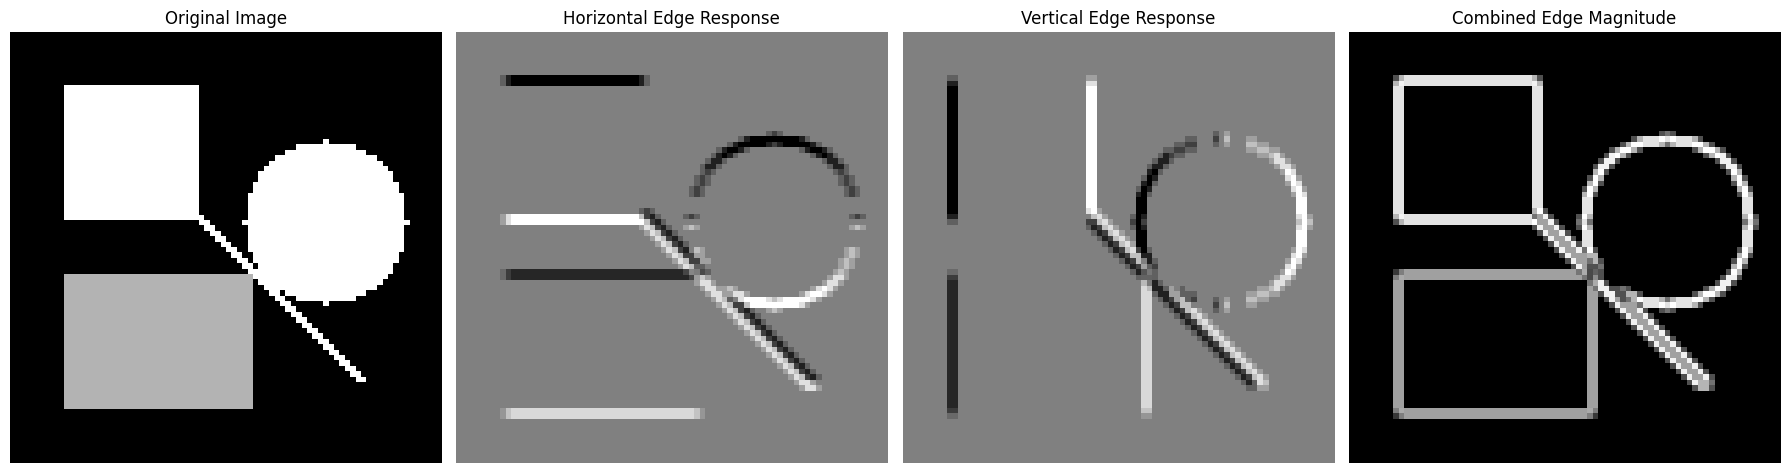

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(horizontal_output, cmap="gray")
axes[1].set_title("Horizontal Edge Response")
axes[1].axis("off")

axes[2].imshow(vertical_output, cmap="gray")
axes[2].set_title("Vertical Edge Response")
axes[2].axis("off")

axes[3].imshow(edge_magnitude, cmap="gray")
axes[3].set_title("Combined Edge Magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Task 1: Implement a Gaussian Blur Kernel (15%)

Create a Gaussian blur kernel and apply it to the image using the `conv2d_simple` function. A Gaussian kernel has higher values in the center and lower values toward the edges, following a Gaussian distribution.

**Hint**: You can use a 3x3 kernel with the following pattern:
```
[[1, 2, 1],
 [2, 4, 2],
 [1, 2, 1]]
```
Don't forget to normalize the kernel (divide by the sum of all elements) to preserve the brightness of the image.

In [8]:
# Add random noise to the image
np.random.seed(42)

noise = np.random.normal(loc=0.0, scale=0.2, size=image.shape)
noisy_image = image + noise

# Keep pixel values in the valid range
noisy_image = np.clip(noisy_image, 0, 1)

In [ ]:
# TODO: Create a 3x3 Gaussian blur kernel
gaussian_kernel = np.array(
    [[1, 2, 1],
     [2, 4, 2],
      [1, 2, 1]]
)

# TODO: Normalize the kernel
gaussian_kernel = gaussian_kernel / gaussian_kernel.sum()

# TODO: Apply the kernel to the noisy image
# Use padding=1, otherwise the blurred image becomes smaller than the input.
blurred_image = conv2d_simple(noisy_image, gaussian_kernel, padding=1)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(noisy_image, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Noisy Image")
axes[1].axis("off")

axes[2].imshow(blurred_image, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Gaussian Blur")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Normalized Gaussian Kernel:")
print(gaussian_kernel)

**Question:**
What happened to the noise after applying the Gaussian blur?
What trade-off do you observe?


**Answers:**



## 2. Convolution Output Size, Stride, and Padding

A convolution changes the spatial size of an image depending on:

- input size
- kernel size
- stride
- padding

For one spatial dimension, the output size is:

$$
\text{Output Size} =
\left\lfloor
\frac{\text{Input Size} - \text{Kernel Size} + 2 \times \text{Padding}}{\text{Stride}}
\right\rfloor + 1
$$

The floor is important: if the kernel does not fit perfectly at the end, the remaining pixels are ignored.

Padding adds zeros around the image.
Stride controls how many pixels the kernel moves at each step.

In [ ]:
settings = [
    ("No padding, stride 1", 1, 0),
    ("Padding 1, stride 1", 1, 1),
    ("Padding 1, stride 2", 2, 1),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, stride, padding) in zip(axes, settings):
    output = conv2d_simple(
        image,
        vertical_edge_kernel,
        stride=stride,
        padding=padding
    )

    ax.imshow(output, cmap="gray")
    ax.set_title(f"{title}\nOutput: {output.shape}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Task 2: Predict Convolution Output Sizes (15%)

Complete the function below. Then use it to calculate the output sizes in the table.

Do the calculation manually first, then verify it with Python.

In [ ]:
def calculate_output_size(input_size, kernel_size, stride, padding):
    """
    Calculate the output size of one spatial dimension after convolution.
    """
    # TODO: implement the formula
    output_size = ...
    return output_size

In [ ]:
examples = [
    # input_size, kernel_size, stride, padding
    (28, 5, 1, 0),
    (32, 3, 1, 1),
    (64, 3, 2, 1),
    (224, 7, 2, 3),
]

for input_size, kernel_size, stride, padding in examples:
    output_size = calculate_output_size(
        input_size,
        kernel_size,
        stride,
        padding
    )

    print(
        f"Input: {input_size}x{input_size}, "
        f"Kernel: {kernel_size}x{kernel_size}, "
        f"Stride: {stride}, Padding: {padding} "
        f"→ Output: {output_size}x{output_size}"
    )

**Question:**
For a 3×3 kernel with stride 1, why does padding 1 preserve the original image size?


**Answers:**



**Question:**
Can padding always preserve the original size if stride is larger than 1?


**Answers:**



## 3. Pooling Operations

Pooling layers reduce the spatial dimensions of the feature maps, which helps to:
- Reduce the number of parameters and computation
- Control overfitting
- Provide a form of translation invariance

The two most common pooling operations are:
- **Max Pooling**: Takes the maximum value from each window
- **Average Pooling**: Takes the average of all values in each window

Let's implement and visualize these pooling operations:

In [ ]:
# Example
feature_map = np.array([
    [1, 2, 0, 1],
    [3, 4, 1, 2],
    [0, 1, 5, 6],
    [1, 2, 7, 8]
])

# Expected max pooling with 2x2, stride 2:
max_pooling_result = [[4, 2],
 [2, 8]]

# Expected avg pooling:
avg_pooling_result = [[2.5, 1.0],
 [1.0, 6.5]]

print(feature_map)
print(f'{max_pooling_result=}')
print(f'{avg_pooling_result=}')

### Task 3: Implement pooling (20%)

In [ ]:
def pool2d(input_image, pool_size=2, stride=2, mode="max"):
    """
    Apply 2D pooling to an input image or feature map.

    Args:
        input_image: 2D numpy array
        pool_size: size of pooling window
        stride: step size
        mode: "max" or "average"

    Returns:
        pooled 2D numpy array
    """

    input_height, input_width = input_image.shape

    output_height = (input_height - pool_size) // stride + 1
    output_width = (input_width - pool_size) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            region = input_image[
                i * stride:i * stride + pool_size,
                j * stride:j * stride + pool_size
            ]

            # TODO: apply max or average pooling
            if mode == "max":
                output[i, j] = ...
            elif mode == "average":
                output[i, j] = ...
            else:
                raise ValueError("mode must be 'max' or 'average'")

    return output

In [ ]:
# Check your function on previous example
print(pool2d(feature_map, stride=2, mode="max"))
print(pool2d(feature_map, stride=2, mode="average"))

In [ ]:
# Visualization of pooling on complex image
max_pooled = pool2d(edge_magnitude, pool_size=2, stride=2, mode="max")
avg_pooled = pool2d(edge_magnitude, pool_size=2, stride=2, mode="average")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(edge_magnitude, cmap="gray")
axes[0].set_title(f"Original Feature Map\n{edge_magnitude.shape}")
axes[0].axis("off")

axes[1].imshow(max_pooled, cmap="gray")
axes[1].set_title(f"Max Pooling\n{max_pooled.shape}")
axes[1].axis("off")

axes[2].imshow(avg_pooled, cmap="gray")
axes[2].set_title(f"Average Pooling\n{avg_pooled.shape}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Question 1:**
How did the spatial size change after pooling?

**Question 2:**
Which pooling operation keeps sharper edges: max pooling or average pooling?

**Question 3:**
Why might max pooling be useful after an edge-detection filter?


**Answers:**



## 4. From Manual Operation to a PyTorch Implementation
PyTorch convolution layers expect image batches in this format:

$$
(batch, channels, height, width)
$$

For example, one grayscale 28×28 image has shape:

$$
(1, 1, 28, 28)
$$

A batch of 64 grayscale images has shape:

$$
(64, 1, 28, 28)
$$

### Number of Trainable Parameters

For a fully connected layer:

$$
\text{parameters} = \text{input features} \times \text{output features} + \text{output features}
$$

The second term is the bias term, one bias for each output neuron.

For a convolutional layer:

$$
\text{parameters} =
\text{out channels} \times
(\text{in channels} \times \text{kernel height} \times \text{kernel width} + 1)
$$

The \(+1\) is the bias term for each filter.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

x = torch.tensor(edge_magnitude, dtype=torch.float32)
x = x.unsqueeze(0).unsqueeze(0)

print("Input shape:", x.shape)

pool = nn.MaxPool2d(kernel_size=2, stride=2)
pooled_x = pool(x)

print("After max pooling:", pooled_x.shape)

### Task 4: Implement a Simple CNN Block (15%)

Complete the CNN block below.

The block should apply:

1. convolution
2. ReLU activation
3. max pooling

This is a common pattern in CNNs:

$$
Conv2d \rightarrow ReLU \rightarrow MaxPool2d
$$

In [ ]:
class SimpleCNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0, pool_size=2):
        super().__init__()

        # TODO: define a convolutional layer
        self.conv = ...

        # TODO: define a max pooling layer
        self.pool = ...

    def forward(self, x):
        # TODO: apply convolution
        x = ...

        # TODO: apply ReLU
        x = ...

        # TODO: apply max pooling
        x = ...

        return x

**Question:**
Before running the code under this cell, try to predict the output shape.

**Answers:**



In [ ]:
input_tensor = torch.randn(1, 1, 28, 28)

cnn_layer = SimpleCNNLayer(
    in_channels=1,
    out_channels=16,
    kernel_size=3,
    padding=1,
    pool_size=2
)

output_tensor = cnn_layer(input_tensor)

print("Input shape:", input_tensor.shape)
print("Output shape:", output_tensor.shape)

**Question:**
Before running the code below, try to calculate how many trainable parameters does the convolutional layer have?

**Answers:**



In [ ]:
num_params = sum(p.numel() for p in cnn_layer.conv.parameters())
print("Number of convolution parameters:", num_params)

## 5. Building a Complete CNN Classifier

A CNN classifier usually has two parts:

1. **Feature extractor**
   Convolution, activation, and pooling layers transform the image into feature maps.

2. **Classifier**
   Fully connected layers use these learned features to predict the class.

In this example, we build a small CNN for grayscale 28×28 images such as MNIST or FashionMNIST.

### Task 5: Building simple CNN using pytorch (20%)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extractor
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Classifier
        # TODO: calculate the correct number of input features
        self.fc1 = nn.Linear(..., 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # First CNN block
        x = ...
        x = ...
        x = ...

        # Second CNN block
        x = ...
        x = ...
        x = ...

        # Flatten feature maps
        x = torch.flatten(x, start_dim=1)

        # Classifier
        x = ...
        x = ...

        return x

In [ ]:
# Let's trace the shape
model = SimpleCNN()

x = torch.randn(4, 1, 28, 28)
output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

**Questions:**
1. Why does the final layer output 10 values?
2. Why do we not apply softmax in the final layer?

**Answers:**



In [ ]:
# Let's count parameteres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)#

## 6. Training and Evaluating the CNN

Now we train the CNN on FashionMNIST.

FashionMNIST images have the same shape as MNIST images:

$$
1 \times 28 \times 28
$$

but the classes are clothing categories instead of digits.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Use smaller subsets to keep training fast
generator = torch.Generator().manual_seed(42)

train_indices = torch.randperm(len(train_dataset), generator=generator)[:10000]
test_indices = torch.randperm(len(test_dataset), generator=generator)[:2000]

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

### Task 6: Implement training loop (15%)

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # TODO: reset gradients from the previous batch
        ...

        # TODO: forward pass
        outputs = ...

        # TODO: compute loss
        loss = ...

        # TODO: backward pass
        ...

        # TODO: update model parameters
        ...

        total_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
num_epochs = 10

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.show()

## 7. Visualizing Feature Maps

The first convolutional layer learns several filters.
Each filter produces one feature map.

By visualizing these feature maps, we can inspect which image structures activate different filters.

In [ ]:
# Get one batch from the test loader
images, labels = next(iter(test_loader))

image = images[0:1].to(device)
label = labels[0].item()

model.eval()

with torch.no_grad():
    conv1_output = model.conv1(image)
    conv1_activations = F.relu(conv1_output)

feature_maps = conv1_activations.squeeze(0).cpu()

print("Input image shape:", image.shape)
print("Feature maps shape:", feature_maps.shape)

In [ ]:
plt.figure(figsize=(4, 4))

plt.imshow(image.squeeze().cpu(), cmap="gray")
plt.title(f"Original Image: {class_names[label]}")
plt.axis("off")

plt.show()

In [ ]:
num_feature_maps = min(8, feature_maps.shape[0])

fig, axes = plt.subplots(1, num_feature_maps, figsize=(18, 3))

for i in range(num_feature_maps):
    axes[i].imshow(feature_maps[i], cmap="gray")
    axes[i].set_title(f"Map {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Questions**

1. Do all feature maps look the same?
2. What kinds of structures seem to activate some filters?
3. Why might different filters be useful for image classification?

**Answers:**



---
#### Feedback

To help improve the exercises, please take 2 minutes to fill out an
[anonymous questionnaire](https://survey.mbp.tf.uni-bielefeld.de/index.php?r=survey/index&sid=177879).
